<a href="https://colab.research.google.com/github/towardsai/ai-tutor-rag-system/blob/main/notebooks/Images_via_OpenAI_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generating and Editing Images via the OpenAI API

Image generation used to mean a separate diffusion vendor with its own API. Now it is a **native capability of the main LLM platforms**: OpenAI serves it through the same SDK you use for text, with dedicated *image models* — the `gpt-image` family, currently led by **`gpt-image-2`** (April 2026). This notebook runs the two workflows that cover most product needs:

1. **Text → Image**, with a text model first *enhancing* your short idea into a rich prompt — a mini-pipeline, and a taste of why prompt quality moves image quality;
2. **Image → Image**: editing an existing picture with a natural-language instruction.

Run top to bottom, the two chain into one flow: the image Workflow 1 generates is the picture Workflow 2 edits.

One naming clarification up front, because it trips people up: **`gpt-image-2` is a model, not an endpoint** — you pass it as `model=` to the Images API (and the same models also power the Responses API's built-in `image_generation` tool). It is not "GPT-5 accessed differently"; it is its own image model.

*(The family also includes the older `gpt-image-1` and `gpt-image-1-mini` from April 2025 — still callable, both on a deprecation path, and not used in this notebook. Everything below runs on `gpt-image-2`, with the previous flagship `gpt-image-1.5` in the picker for comparison.)*

**Vendor note:** deliberately single-vendor (OpenAI SDK directly; models current **as of August 2026**, pickers editable). Gemini generates and edits images natively too — same idea, different SDK — so the pattern here transfers.

## 🧭 What You'll Learn

- How to call the current flagship image model, `gpt-image-2`, and what its reasoning pass buys you over `gpt-image-1.5`
- The size rules that come with it: arbitrary resolutions, and the constraints on them
- The two-call Text-to-Image workflow: `responses.create()` to enhance the prompt, `images.generate()` to render it
- Editing an existing image with `images.edit()` and a plain-English instruction — by default, the one Workflow 1 just generated
- Run-All safety: a workflow selector whose unselected branch *skips cleanly* instead of crashing

## 1. Setup: Environment, Dependencies, and the API Key

Only `OPENAI_API_KEY` is needed here — Colab Secrets or a local `.env`, loaded by the standard course key loader. *(The key stays in the environment; never print any part of it — even a prefix narrows a brute-force search.)*

In [1]:
# ============================================================
# ⚙️ Setup — environment, dependencies, API key
# ============================================================
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import importlib
    import site
    import subprocess

    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q", "-U",
            "tai-aitutor==0.0.3",
            "openai==2.46.0",
        ],
        check=True,
    )
    importlib.reload(site)  # make newly installed packages importable without a runtime restart

if not IN_COLAB:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
    # Locally: pip install "tai-aitutor==0.0.3" "openai==2.46.0" once;
    # keys live in a .env file at the repo root.

from tai_aitutor import setup_notebook

# The standard course key loader — Colab Secrets or a local .env, same code path.
setup_notebook(required_keys=["OPENAI_API_KEY"])

from openai import OpenAI

openai_client = OpenAI()  # reads OPENAI_API_KEY from the environment

print(f"✅ Setup complete — {'Colab' if IN_COLAB else 'local'}")

✅ Setup complete — local


## 2. Pick Your Models, Workflow, and Size

Two image models are worth reaching for as of August 2026 — same API, different price/quality points:

- **`gpt-image-2`** (April 2026) — the flagship, and the default here. It runs a reasoning pass over your prompt *before* rendering, which is why it holds up on structured work (diagrams, infographics, posters, comics), renders multilingual text far more reliably, and follows multi-constraint instructions instead of averaging them. It is also the only one that takes arbitrary resolutions.
- **`gpt-image-1.5`** — the previous flagship: still strong, and cheaper per image at the same tier.

Both sit behind API organization verification, so a brand-new key may need that step first.

`quality` sets how much compute (and money) each image gets; `auto` lets the API decide. **Size** is where the two differ: `gpt-image-2` accepts any `WIDTHxHEIGHT` whose sides are multiples of 16, with the long edge ≤ 3840px and the aspect ratio inside 1:3–3:1; `gpt-image-1.5` only takes the fixed 1024-based sizes. Both knobs move the bill — images are charged as output *tokens*, so higher quality and more pixels cost more; price them for your own model and size at [openai.com/api/pricing](https://openai.com/api/pricing) before shipping anything.

The **workflow selector** defaults to **both workflows in sequence** — generate, then edit the result. Pick a single workflow instead and the other half skips itself cleanly, so *Run All never crashes*.

In [2]:
IMAGE_MODEL = "gpt-image-2"  # @param ["gpt-image-2", "gpt-image-1.5"] {allow-input: true}
TEXT_MODEL = "gpt-5.6-luna"  # @param {type:"string"}  (enhances the prompt in workflow 1)
REASONING_EFFORT = "low"  # @param ["minimal", "low", "medium", "high"]

IMAGE_QUALITY = "medium"  # @param ["low", "medium", "high", "auto"]
IMAGE_SIZE = "1024x1024"  # @param ["1024x1024", "1024x1536", "1536x1024", "2048x2048", "2048x1152", "auto"] {allow-input: true}

SELECTED_WORKFLOW = "Both — Generate then Edit"  # @param ["Both — Generate then Edit", "Text-to-Image (Prompt Enhancement)", "Image Input (Editing)"]

# gpt-image-1.5 is limited to these; only gpt-image-2 takes arbitrary sizes.
GPT_IMAGE_1_5_SIZES = ["1024x1024", "1024x1536", "1536x1024", "auto"]


def workflow_selected(name):
    """True if `name` is picked above (or "Both" is); otherwise print a clean skip.

    The unselected branch must SKIP, not crash — a notebook should always be
    safe to "Run All", whatever the selector says.
    """
    if SELECTED_WORKFLOW in (name, "Both — Generate then Edit"):
        return True
    print(
        f"⏭️ Skipping — SELECTED_WORKFLOW is set to {SELECTED_WORKFLOW!r}.\n"
        f"   Set it to {name!r} and re-run to use this section."
    )
    return False


if IMAGE_MODEL != "gpt-image-2" and IMAGE_SIZE not in GPT_IMAGE_1_5_SIZES:
    print(f"⚠️ {IMAGE_SIZE} is a gpt-image-2 size — {IMAGE_MODEL} only accepts {GPT_IMAGE_1_5_SIZES}.")

print(f"Image model: {IMAGE_MODEL} | quality: {IMAGE_QUALITY} | size: {IMAGE_SIZE}")
print(f"Workflow: {SELECTED_WORKFLOW}")

Image model: gpt-image-2 | quality: medium | size: 1024x1024
Workflow: Both — Generate then Edit


## 3. Workflow 1 — Text to Image, with Prompt Enhancement

Short prompts make generic images. So the first call is to a **text model**: it expands your idea into a rich prompt (composition, lighting, mood, style, any text to render), and only then does the **image model** paint it. Two models, two calls, each doing what it is best at — the smallest "pipeline" in the course.

In [3]:
USER_PROMPT = "A robot tutor explaining retrieval augmented generation at a chalkboard"  # @param {type:"string"}

In [4]:
enhanced_prompt = None

if workflow_selected("Text-to-Image (Prompt Enhancement)"):
    response = openai_client.responses.create(
        model=TEXT_MODEL,
        reasoning={"effort": REASONING_EFFORT},
        max_output_tokens=2000,
        instructions=(
            "You turn short image ideas into rich image-generation prompts. "
            "Specify subject, composition, lighting, mood, style, and any text "
            "that must appear rendered legibly. Reply with the prompt only."
        ),
        input=USER_PROMPT,
    )

    enhanced_prompt = response.output_text  # every Responses reply exposes its final text here
    print(enhanced_prompt)
    print(f"\n({response.usage.input_tokens} in / {response.usage.output_tokens} out tokens)")

A friendly humanoid robot tutor standing beside a large classroom chalkboard, explaining “Retrieval-Augmented Generation” with clear hand-drawn diagrams: a document database, search arrows, retrieved context cards, and an AI language model producing an answer. The exact title “RETRIEVAL-AUGMENTED GENERATION” must appear prominently and legibly across the top of the board, with labeled terms “QUERY,” “RETRIEVE,” “CONTEXT,” and “GENERATE.” Medium-wide composition, robot positioned on the right and chalkboard filling the background, expressive teaching gesture, warm intelligent eyes, subtle classroom details, scattered chalk and books. Soft warm overhead lighting with gentle rim light on the robot, cozy academic atmosphere, approachable and intellectually curious mood. Detailed cinematic digital illustration, polished concept art, realistic metal textures, chalk dust in the air, balanced blue-and-warm color palette, crisp readable lettering, no extra text, no misspellings.

(59 in / 196 o

*(Note the retrieval pattern for the reply: `response.output_text`. The `output` list holds typed items — reasoning, messages, tool calls — and indexing into it by position (`output[1].content[0]...`) breaks the moment the model adds a reasoning item. `output_text` is the stable accessor.)*

Now the image call. Two things worth noticing in the parameters:

- `n=1` — the Images API can return up to 10 variations per call; each one is billed.
- **No `response_format`, no `style`** — those are DALL·E-era parameters. The `gpt-image` family always returns Base64 (`b64_json`) and takes its stylistic direction from the prompt itself. If you want something other than a PNG back, that is `output_format` (`png` / `jpeg` / `webp`) plus `output_compression`, not `response_format`.

Saved to generated_image.png


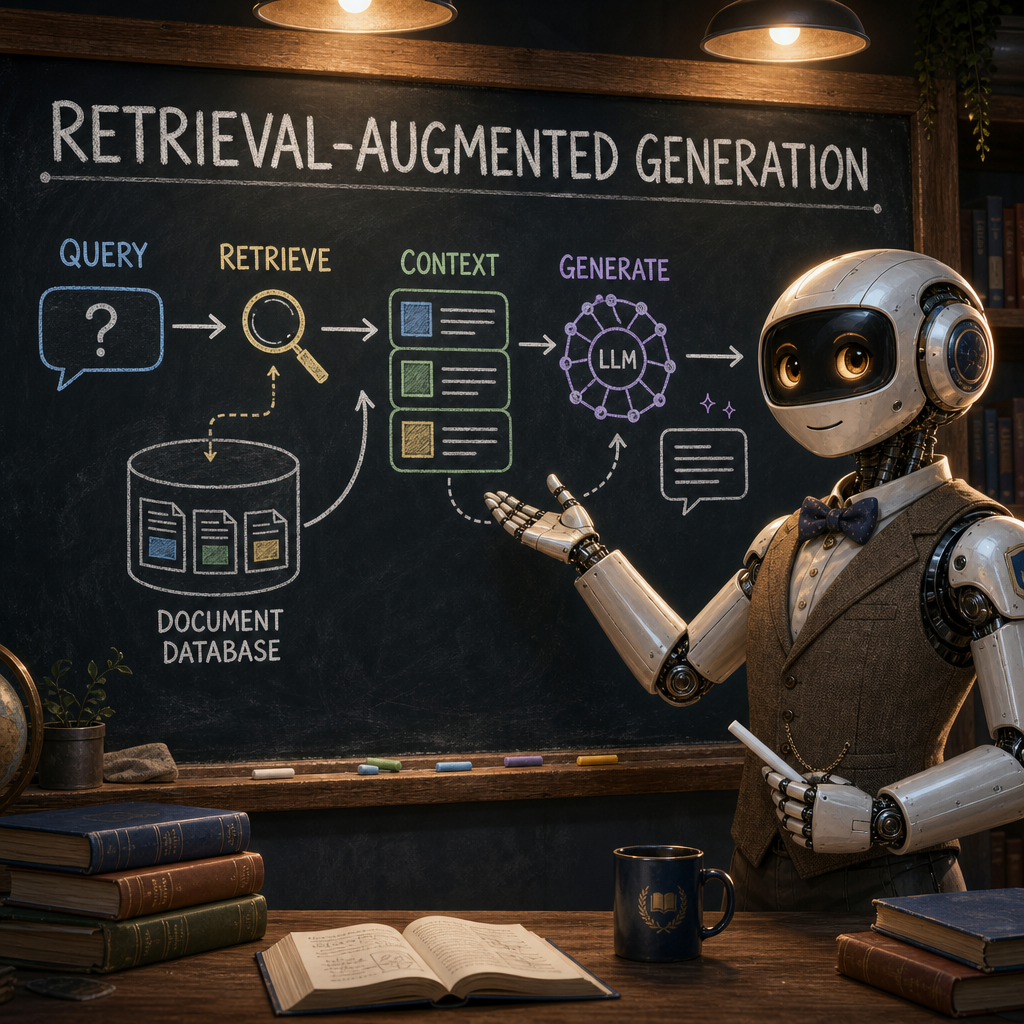

In [5]:
import base64
import pathlib

from IPython.display import Image as IPythonImage, display

if workflow_selected("Text-to-Image (Prompt Enhancement)") and enhanced_prompt:
    image_response = openai_client.images.generate(
        model=IMAGE_MODEL,
        prompt=enhanced_prompt,
        size=IMAGE_SIZE,
        quality=IMAGE_QUALITY,
        n=1,
    )

    image_bytes = base64.b64decode(image_response.data[0].b64_json)
    pathlib.Path("generated_image.png").write_bytes(image_bytes)

    print("Saved to generated_image.png")
    display(IPythonImage(data=image_bytes))

**What just happened?** A single cheap text call wrote a better prompt than most of us would, and the image model rendered it. Re-run the two cells with the same `USER_PROMPT` and you will get a *different* enhanced prompt and a different image — both models are stochastic. When a product needs reproducibility, store the enhanced prompt, not just the user's input.

## 4. Workflow 2 — Editing an Existing Image

The same image models accept **image input**: give `images.edit()` a source picture plus an instruction, and it returns the edited version — object swaps, style transfer, background changes, all in plain English. `gpt-image-2` reads every input image at full fidelity (there is no `input_fidelity` knob to set — it is always on) and accepts *several* reference images in one call, so "put the product from image 1 into the scene from image 2" is a single request. By default the source here is `generated_image.png` — the image Workflow 1 just saved — so a top-to-bottom run generates and then edits, hands-free. To edit your own picture, point `LOCAL_IMAGE_PATH` at it (in Colab, an upload prompt appears if the file isn't there). No image → the cell says so and moves on (Run-All safe, as always).

Editing 'generated_image.png' → "Update the image: change the robot's color to black-grey, and change the discussed topic and content in board to AI Agents"


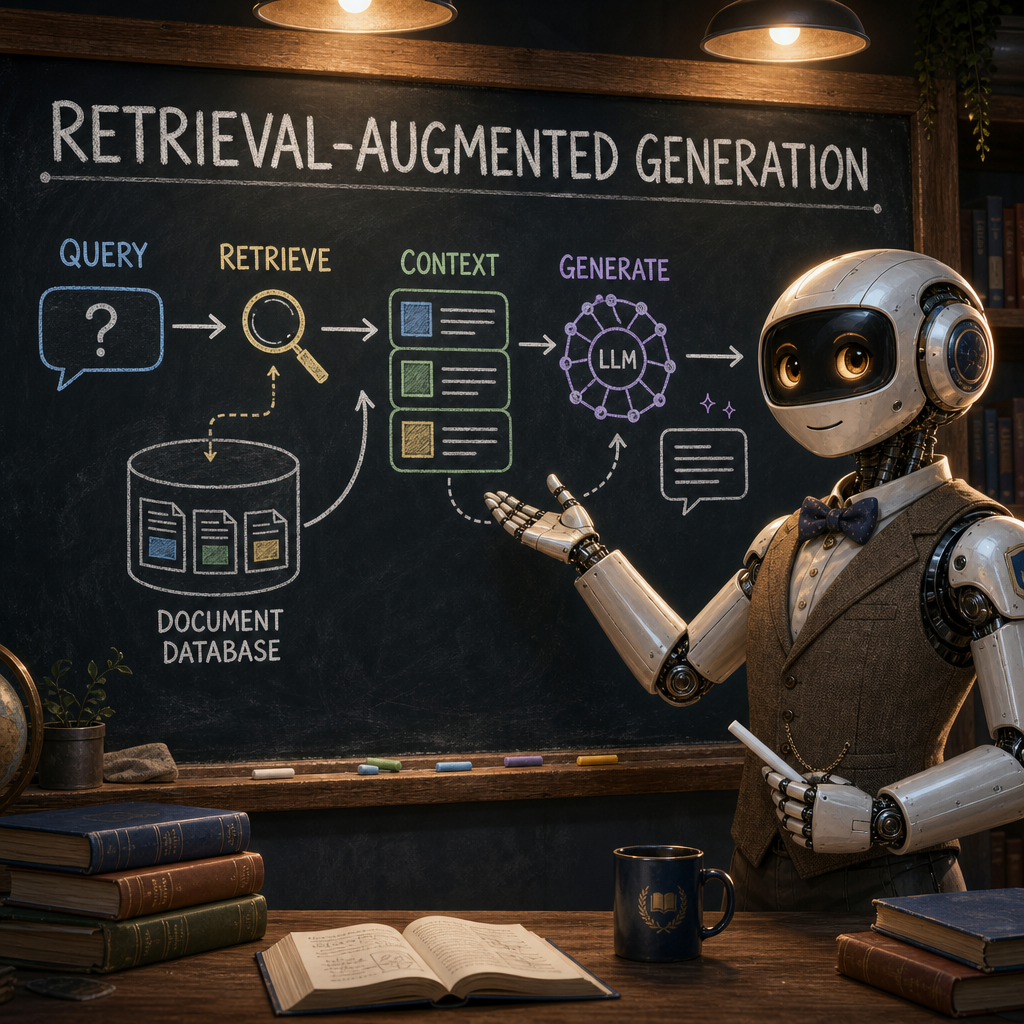

Saved to edited_image.png


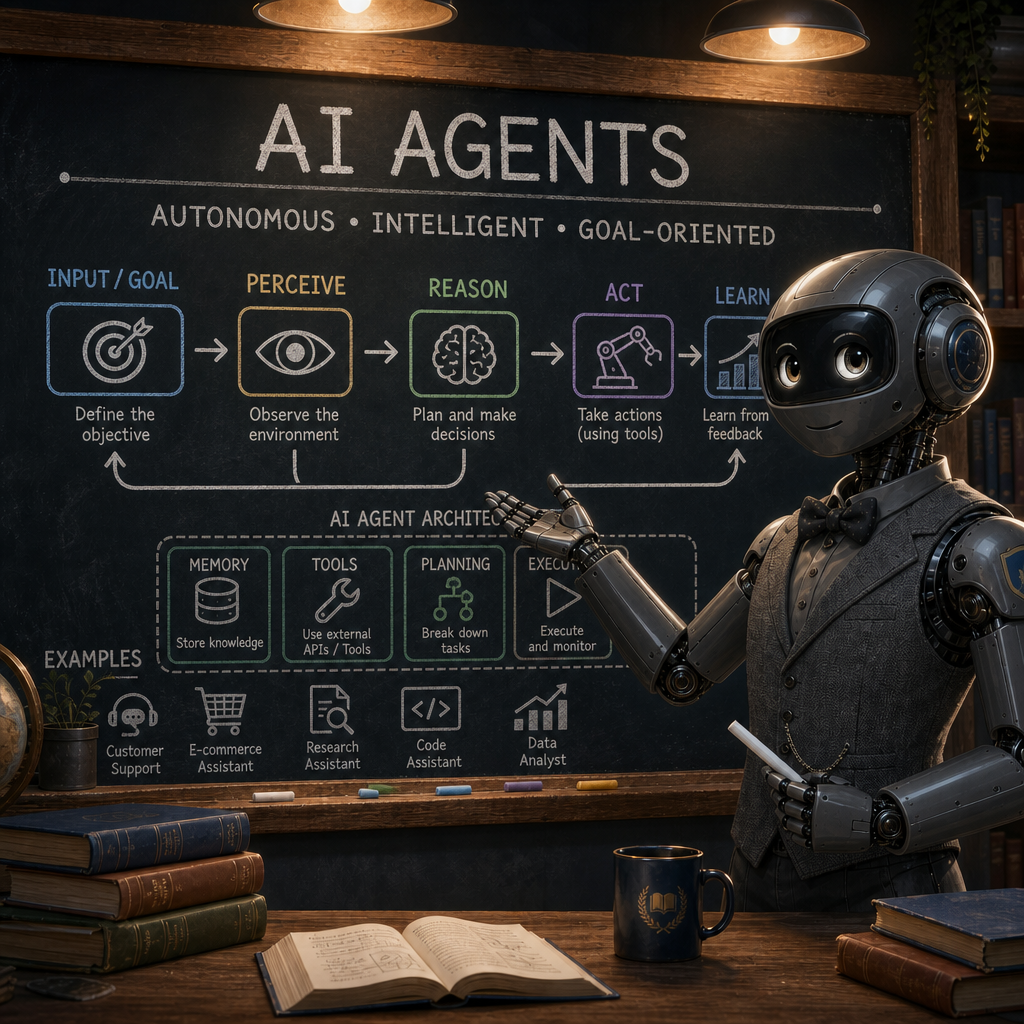

In [6]:
EDIT_PROMPT = "Update the image: change the robot's color to black-grey, and change the discussed topic and content in board to AI Agents"  # @param {type:"string"}
LOCAL_IMAGE_PATH = "generated_image.png"  # @param {type:"string"}  (defaults to Workflow 1's output — point it at your own file to edit that instead)

if workflow_selected("Image Input (Editing)"):
    # --- get a source image: Workflow 1's output (or any existing path), else an upload ---
    source_path = None
    if pathlib.Path(LOCAL_IMAGE_PATH).exists():
        source_path = LOCAL_IMAGE_PATH  # the image Workflow 1 just saved, by default
    elif IN_COLAB:
        from google.colab import files

        print("Choose a PNG/JPG/WebP to edit:")
        uploaded = files.upload()
        source_path = next(iter(uploaded), None)

    if source_path is None:
        print("⏭️ No source image provided — upload one (or set LOCAL_IMAGE_PATH) and re-run.")
    else:
        print(f"Editing {source_path!r} → {EDIT_PROMPT!r}")
        display(IPythonImage(filename=source_path, width=380))

        with open(source_path, "rb") as image_file:
            edit_response = openai_client.images.edit(
                model=IMAGE_MODEL,       # same models, same quality/size knobs
                image=image_file,
                prompt=EDIT_PROMPT,
                size=IMAGE_SIZE,
                quality=IMAGE_QUALITY,
            )

        edited_bytes = base64.b64decode(edit_response.data[0].b64_json)
        pathlib.Path("edited_image.png").write_bytes(edited_bytes)

        print("Saved to edited_image.png")
        display(IPythonImage(data=edited_bytes))

**What just happened?** Editing is generation *conditioned on your pixels* — the model re-renders the scene under your instruction rather than filtering the original. That is why it can change materials, lighting, or objects coherently, and also why fine details (faces, logos, small text) can drift: budget review time for anything brand-sensitive. `gpt-image-2` drifts noticeably less than its predecessors here, which is most of the reason it costs more.

## 🧪 Your Turn

- Run the same `USER_PROMPT` on `gpt-image-1.5`, then on `gpt-image-2` — where is the difference visible, and is it worth the price gap for your use case?
- Ask for **rendered text** (a poster, a sign, a labelled diagram, a line of non-Latin script) — structured layout and text fidelity are where `gpt-image-2` earns its price.
- Skip the enhancement call and feed `USER_PROMPT` straight to `images.generate()` — how much of the quality was the *prompt*?
- Push the resolution: `IMAGE_SIZE = "2048x2048"` on `gpt-image-2`. Try it on `gpt-image-1.5` too — that is the warning the setup cell prints.
- Break the chain: point `LOCAL_IMAGE_PATH` at a photo of your own (or pick the editing workflow alone and upload one in Colab) — same edit call, your pixels.

## 🔑 Key Takeaways

- **`gpt-image-2` is a model, not an endpoint** — `model=` on the Images API. `gpt-image-1.5` is the previous flagship and a cheaper fallback.
- **What `gpt-image-2` buys you**: a planning pass before rendering, so structured work (diagrams, posters, infographics) and multilingual text hold together, plus arbitrary sizes — sides a multiple of 16, long edge ≤ 3840px, aspect within 1:3–3:1.
- **Quality × size is the bill.** Images are charged as output tokens, so both knobs move cost by a wide margin — iterate cheap and small, finalize at the setting you ship, and check current prices at openai.com/api/pricing rather than trusting a number in a notebook.
- **Prompt enhancement is a pipeline pattern**: a fraction-of-a-cent text call measurably upgrades a several-cent image call. Read Responses replies via `response.output_text`, never by indexing `output[N]`.
- The gpt-image family **always returns Base64** and has no `style`/`response_format` parameters — style lives in the prompt, file type in `output_format`.
- **Editing = conditioned generation**: `images.edit(model=…, image=…, prompt=…)` re-renders under instruction; `gpt-image-2` reads inputs at full fidelity and takes multiple reference images, but expect occasional small-detail drift.
- **The workflows chain**: by default Workflow 2 edits the `generated_image.png` Workflow 1 saved — generation feeding editing, the smallest image pipeline.
- The same models are exposed as the Responses API's built-in **`image_generation` tool**, so an *agent* can decide mid-conversation to draw — and Gemini offers native image generation through its own SDK too.
- **Run-All safety is a design requirement**: unselected branches skip with a message; they never `assert False`.
- ⏭️ *Next: agents — models that decide for themselves which tools (search, code, even image generation) to call, and in which order.*